# S-01: first Phase 07 scenario-simulation worked example (level-residual hybrid)

**Context.** Phase 07 is this dissertation's actual novel deliverable and has been "PLANNED, not started" throughout the project. This notebook is the first bounded worked example proving the whole scenario-simulation mechanism end-to-end -- not the full Phase 07 sweep.

**Builds directly on:**
- **D-46** (2026-07-01): scoped the long-range scenario requirements and identified the Semenov et al. CMIP6-based climate dataset.
- **D-52** (2026-07-05): confirmed the delivered files (`data/Simulated Climate Data/`) are genuinely North-Wyke-matched, and **decided** the missing-driver strategy: historical-day resampling (climatology-by-analogue), not a raw Copernicus pull.
- **U-03** (D-63): already answered D-46's "extrapolation-range check" requirement directly on the candidate models -- trees plateau, SARIMAX extrapolates unbounded. Per user confirmation, **B-08 is superseded for Phase 07's purposes** by this finding.
- **A deep-research literature pass** (this session): recommended a **level-residual hybrid** architecture -- an explicit trend model carries the extrapolation (climate + livestock axes), a tree ensemble corrects only the residual (near-stationary, sidesteps the tree-extrapolation-ceiling U-03 found). Per user confirmation, the trend component is a **parametric** model (Ridge) for this pass, not a mechanistic process model (SPACSYS, already validated at North Wyke, is logged as a future research direction, not attempted here). Also adopted: monotonic constraints on livestock density in XGB/LightGBM, and dropping `fx_USTAR_mean`/`fx_SHF_mean` entirely (true EC-tower turbulence quantities with no climate-scenario-product source at all).

**Scope of this first pass (user-confirmed, then extended to all 3 towers + per-model breakdown per direct user request):** SSP2-4.5, ensemble-mean across all 5 GCMs x 100 realizations, averaged per day-of-year over a 2041-2060 window ("the 2050s"), **all three towers (T2, T4, T9)**. Livestock scenarios: baseline (1.0x) plus 2.0x and 3.0x multipliers on the historical day-of-year climatology of `fx_lsu_dens` (a naive multiplier -- explicitly flagged as a known simplification per the literature's own caution against naive column-scaling; self-consistent mechanistic management-timeline construction is a follow-up refinement, not attempted here). Every figure below breaks out **all three towers and all three residual-tree models individually** (RF/XGB/LightGBM), not just an ensemble mean.

In [1]:
import sys
ROOT = r"c:\Users\Nicholas\Documents\COMP0191 MSc Artificial Intelligence for Sustainable Development Project"
sys.path.insert(0, ROOT)
sys.path.insert(0, ROOT + r"\src")
sys.path.insert(0, ROOT + r"\src\features")
sys.path.insert(0, ROOT + r"\src\models")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import build_scenario_drivers as bsd
import scenario_hybrid as sh

RESULTS = rf"{ROOT}\results"
FIG_DIR = rf"{RESULTS}\figures"
MULTIPLIERS = [1.0, 2.0, 3.0]
TOWERS = [2, 4, 9]
MODEL_COLORS = {"RF": "tab:green", "XGB": "tab:orange", "LightGBM": "tab:blue", "Trend": "tab:gray"}
SSP = "ssp245"
YEAR_START, YEAR_END = 2041, 2060

## Step 1: fit the level-residual hybrid on real historical data

Trend (Ridge): `fx_TA_mean`, `fx_lsu_dens`, `fx_DOY_sin/cos` + tower dummies, fit **once** on the full pooled real record (T2+T4+T9) -- deliberately a single fit, not per-anchor, the specific fix for the SARIMAX instability U-03 found. Residual trees (RF/XGB/LightGBM): B-10's exact hyperparameters (D-41/D-54, no new HPO), full feature set minus `fx_USTAR_mean`/`fx_SHF_mean`, with a monotonic constraint (`fx_lsu_dens` non-decreasing) on XGB/LightGBM. **One hybrid model serves all three towers** (the pooled fit + tower dummies already encode tower identity), so this fit does not need to be repeated per tower.

In [2]:
T = bsd.load_towers()

pool = []
for t in TOWERS:
    df = T[t].copy()
    df["is_t2"] = 1.0 if t == 2 else 0.0
    df["is_t4"] = 1.0 if t == 4 else 0.0
    df["is_t9"] = 1.0 if t == 9 else 0.0
    pool.append(df[df["y_gapfilled"].notna()])
pool_df = pd.concat(pool)
print(f"Pooled training rows: {len(pool_df)}")

trend_model, trend_cols = sh.fit_trend_model(pool_df)
coefs = dict(zip(trend_cols, trend_model.named_steps["ridge"].coef_.round(3)))
print("Trend model (scaled) coefficients:", coefs)

feat_cols = sh.s01_feat_cols(pool_df.columns)
print(f"\nResidual-tree feature count: {len(feat_cols)} (USTAR/SHF excluded: "
      f"{'fx_USTAR_mean' not in feat_cols and 'fx_SHF_mean' not in feat_cols})")

imp, tree_models = sh.fit_residual_trees(pool_df, trend_model, trend_cols, feat_cols)
print("Residual RF/XGB/LightGBM fit.")

Pooled training rows: 8772
Trend model (scaled) coefficients: {'fx_TA_mean': np.float64(2.171), 'fx_lsu_dens': np.float64(27.034), 'fx_DOY_sin': np.float64(2.531), 'fx_DOY_cos': np.float64(1.92), 'is_t2': np.float64(0.906), 'is_t4': np.float64(-1.842), 'is_t9': np.float64(0.936)}

Residual-tree feature count: 42 (USTAR/SHF excluded: True)


Residual RF/XGB/LightGBM fit.


## Step 2: verify the monotonic constraint is actually respected

A synthetic sweep of `fx_lsu_dens` at fixed other-feature values (mirroring U-03's own perturbation-response methodology) should show a non-decreasing XGB/LightGBM residual prediction -- verify this directly rather than trusting the hyperparameter silently. This is a property of the fitted model itself (tower-agnostic), so a single representative row (Tower 4) is sufficient.

In [3]:
row0 = pool_df[pool_df["tower"] == 4].iloc[[0]][feat_cols].copy()
sweep_vals = np.linspace(0, 10, 21)
sweep_preds = {"RF": [], "XGB": [], "LightGBM": []}
for v in sweep_vals:
    row = row0.copy()
    row["fx_lsu_dens"] = v
    Xi = imp.transform(row.values)
    for name, m in tree_models.items():
        sweep_preds[name].append(float(m.predict(Xi)[0]))

for name in ["XGB", "LightGBM"]:
    diffs = np.diff(sweep_preds[name])
    print(f"{name}: monotonic non-decreasing = {(diffs >= -1e-6).all()} (min step = {diffs.min():.4f})")
print(f"RF (no native monotonic constraint, expected non-monotonic OK): "
      f"range = {min(sweep_preds['RF']):.2f} to {max(sweep_preds['RF']):.2f}")

XGB: monotonic non-decreasing = True (min step = 0.0000)
LightGBM: monotonic non-decreasing = True (min step = 0.0000)
RF (no native monotonic constraint, expected non-monotonic OK): range = -11.67 to 5.52


## Step 3: load the CMIP6 scenario climatology and build the scenario driver frames for all 3 towers

In [4]:
clim = bsd.load_cmip6_climatology(SSP, YEAR_START, YEAR_END)

scenarios = {}  # {(tower, mult): frame}
for tower in TOWERS:
    for mult in MULTIPLIERS:
        scenarios[(tower, mult)] = bsd.build_scenario_fx_frame(tower, T, clim, lsu_multiplier=mult)
print(f"Built {len(scenarios)} scenario frames ({len(TOWERS)} towers x {len(MULTIPLIERS)} multipliers), "
      f"each {scenarios[(4, 1.0)].shape}")

print()
for tower in TOWERS:
    tr_max = float(pool_df[pool_df.tower == tower]["fx_lsu_dens"].max())
    print(f"Tower {tower}: own-tower training max fx_lsu_dens = {tr_max:.2f}")
    for mult in MULTIPLIERS:
        scen = scenarios[(tower, mult)]
        print(f"    {mult}x: scenario fx_lsu_dens max = {scen['fx_lsu_dens'].max():.2f}")

[build_scenario_drivers] ssp=ssp245 years=2041-2060: 500 realization-files loaded, 10000 samples/day-of-year on average


Built 9 scenario frames (3 towers x 3 multipliers), each (365, 42)

Tower 2: own-tower training max fx_lsu_dens = 4.51
    1.0x: scenario fx_lsu_dens max = 0.71
    2.0x: scenario fx_lsu_dens max = 1.43
    3.0x: scenario fx_lsu_dens max = 2.14
Tower 4: own-tower training max fx_lsu_dens = 4.99
    1.0x: scenario fx_lsu_dens max = 2.48
    2.0x: scenario fx_lsu_dens max = 4.95
    3.0x: scenario fx_lsu_dens max = 7.43
Tower 9: own-tower training max fx_lsu_dens = 5.65
    1.0x: scenario fx_lsu_dens max = 2.58
    2.0x: scenario fx_lsu_dens max = 5.16
    3.0x: scenario fx_lsu_dens max = 7.74


## Step 4: predict every (tower, multiplier) scenario + per-model breakdown + AOA / ensemble-disagreement OOD flagging

In [5]:
Xtr_full = imp.transform(pool_df[feat_cols].values)

results_rows = []
combined_by_key = {}
trend_by_key = {}
resid_by_key = {}  # {(tower, mult): {model_name: array}}

for tower in TOWERS:
    real_hist_mean = float(T[tower]["y_gapfilled"].mean())
    Xtr_tower = imp.transform(pool_df[pool_df.tower == tower][feat_cols].values)
    for mult in MULTIPLIERS:
        scen = scenarios[(tower, mult)]
        combined, trend_p, resid_p = sh.predict_scenario(trend_model, trend_cols, imp, tree_models, feat_cols, scen)
        combined_by_key[(tower, mult)] = combined
        trend_by_key[(tower, mult)] = trend_p
        resid_by_key[(tower, mult)] = resid_p

        Xsc = imp.transform(scen[feat_cols].values)
        d, thresh, flagged = sh.dissimilarity_index(Xtr_full, Xsc)

        resid_matrix = np.array(list(resid_p.values()))
        ensemble_spread = resid_matrix.std(axis=0).mean()

        season = scen.index.month.map(lambda m: {12: "DJF", 1: "DJF", 2: "DJF", 3: "MAM", 4: "MAM", 5: "MAM",
                                                    6: "JJA", 7: "JJA", 8: "JJA", 9: "SON", 10: "SON", 11: "SON"}[m])
        seasonal = pd.Series(combined, index=scen.index).groupby(season).mean()

        row = {
            "tower": tower, "multiplier": mult,
            "real_historical_mean": real_hist_mean,
            "annual_mean": combined.mean(),
            "trend_mean": trend_p.mean(),
            "residual_mean": resid_matrix.mean(axis=0).mean(),
        }
        for name in ["RF", "XGB", "LightGBM"]:
            row[f"residual_{name}"] = resid_p[name].mean()
        row.update({
            "DJF": seasonal.get("DJF", np.nan), "MAM": seasonal.get("MAM", np.nan),
            "JJA": seasonal.get("JJA", np.nan), "SON": seasonal.get("SON", np.nan),
            "aoa_flagged_pct": flagged.mean() * 100,
            "ensemble_disagreement": ensemble_spread,
            "scenario_lsu_max": float(scen["fx_lsu_dens"].max()),
        })
        results_rows.append(row)

summary = pd.DataFrame(results_rows)
pd.set_option("display.width", 160)
print(summary.round(3).to_string(index=False))

summary.to_csv(f"{RESULTS}/s01_scenario_summary.csv", index=False)
print(f"\n[OK] Saved s01_scenario_summary.csv ({len(summary)} rows: {len(TOWERS)} towers x {len(MULTIPLIERS)} multipliers)")

 tower  multiplier  real_historical_mean  annual_mean  trend_mean  residual_mean  residual_RF  residual_XGB  residual_LightGBM    DJF    MAM     JJA    SON  aoa_flagged_pct  ensemble_disagreement  scenario_lsu_max
     2         1.0                19.395       23.305      19.654          3.651        6.107         4.033              0.812 24.825 26.358  23.237 18.783            0.000                  2.442             0.713
     2         2.0                19.395       27.608      24.409          3.198        4.750         4.033              0.812 25.370 30.556  31.009 23.400            0.000                  2.092             1.426
     2         3.0                19.395       31.191      29.164          2.028        1.238         4.033              0.812 25.917 34.218  36.862 27.616            0.000                  2.918             2.139
     4         1.0                29.953       29.350      30.233         -0.883       -4.360         2.295             -0.584 16.676 33.106  39

## Step 5: persist the frozen model artifact (closes D-46 requirement 1)

One hybrid model (trend + 3 residual models) serves all three towers via the pooled fit + tower dummies -- a single set of artifacts, not one per tower.

In [6]:
import os
import joblib
os.makedirs(f"{RESULTS}/models", exist_ok=True)
joblib.dump(trend_model, f"{RESULTS}/models/s01_trend.joblib")
joblib.dump(imp, f"{RESULTS}/models/s01_imputer.joblib")
for name, m in tree_models.items():
    joblib.dump(m, f"{RESULTS}/models/s01_{name.lower()}_residual.joblib")
print("[OK] Frozen model artifacts saved to results/models/")

[OK] Frozen model artifacts saved to results/models/


## Step 6: visualization -- all 3 towers, all 3 residual models broken out individually

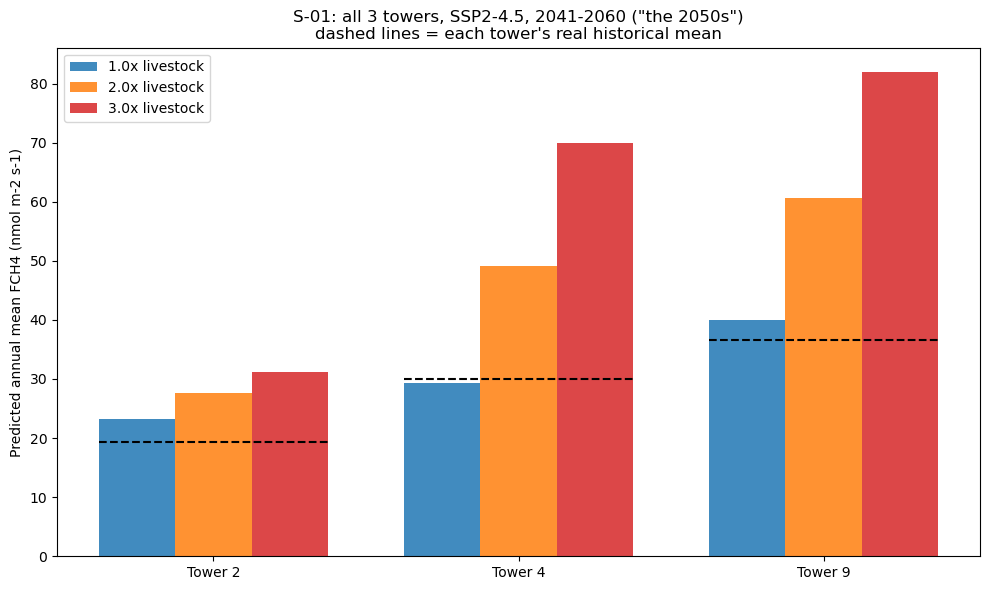

[OK] Saved s01_scenario_comparison_all_towers.png


In [7]:
# Figure 1: annual mean prediction, grouped bar chart, one group per tower, bars = multipliers
fig, ax = plt.subplots(figsize=(10, 6))
width = 0.25
x = np.arange(len(TOWERS))
colors = {1.0: "tab:blue", 2.0: "tab:orange", 3.0: "tab:red"}
for i, mult in enumerate(MULTIPLIERS):
    vals = [summary[(summary.tower == t) & (summary.multiplier == mult)]["annual_mean"].iloc[0] for t in TOWERS]
    ax.bar(x + (i - 1) * width, vals, width, label=f"{mult}x livestock", color=colors[mult], alpha=0.85)
for i, t in enumerate(TOWERS):
    real_mean = summary[summary.tower == t]["real_historical_mean"].iloc[0]
    ax.plot([x[i] - 1.5 * width, x[i] + 1.5 * width], [real_mean, real_mean], "k--", linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels([f"Tower {t}" for t in TOWERS])
ax.set_ylabel("Predicted annual mean FCH4 (nmol m-2 s-1)")
ax.set_title(f"S-01: all 3 towers, SSP2-4.5, {YEAR_START}-{YEAR_END} (\"the 2050s\")\n"
             "dashed lines = each tower's real historical mean")
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/s01_scenario_comparison_all_towers.png", dpi=100)
plt.show()
print("[OK] Saved s01_scenario_comparison_all_towers.png")

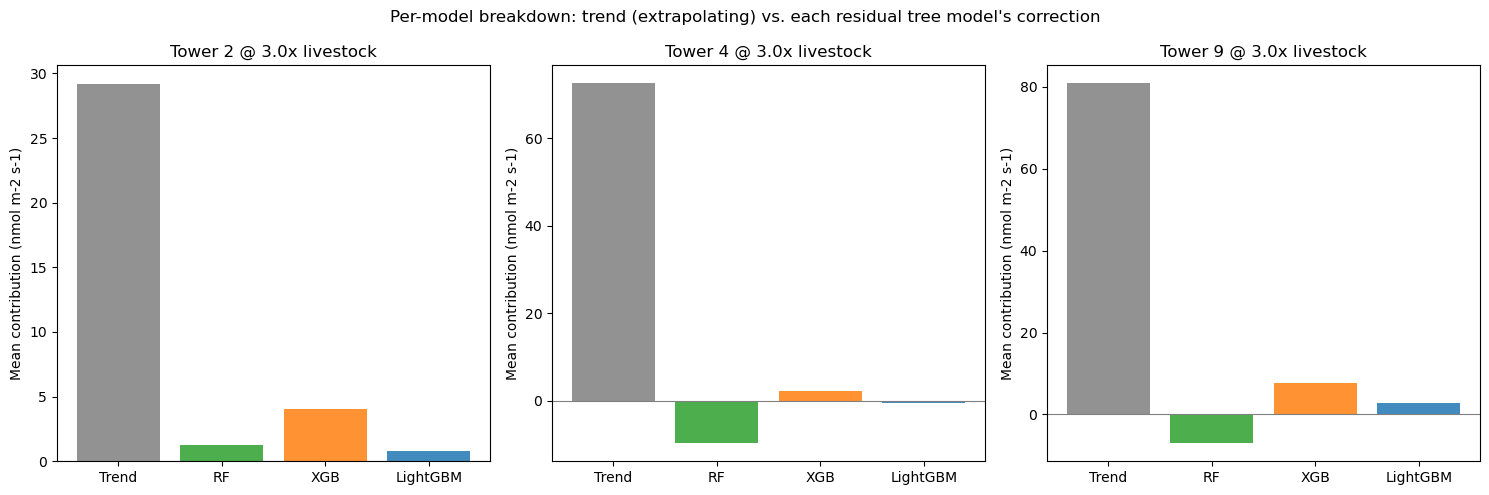

[OK] Saved s01_per_model_breakdown.png


In [8]:
# Figure 2: per-model breakdown (Trend + RF + XGB + LightGBM residual contributions), one panel per tower, at 3.0x
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
mult_show = 3.0
for ax, tower in zip(axes, TOWERS):
    trend_mean = trend_by_key[(tower, mult_show)].mean()
    resid_means = {name: resid_by_key[(tower, mult_show)][name].mean() for name in ["RF", "XGB", "LightGBM"]}
    names = ["Trend"] + list(resid_means.keys())
    vals = [trend_mean] + list(resid_means.values())
    bar_colors = [MODEL_COLORS[n] for n in names]
    ax.bar(names, vals, color=bar_colors, alpha=0.85)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_title(f"Tower {tower} @ {mult_show}x livestock")
    ax.set_ylabel("Mean contribution (nmol m-2 s-1)")
fig.suptitle("Per-model breakdown: trend (extrapolating) vs. each residual tree model's correction")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/s01_per_model_breakdown.png", dpi=100)
plt.show()
print("[OK] Saved s01_per_model_breakdown.png")

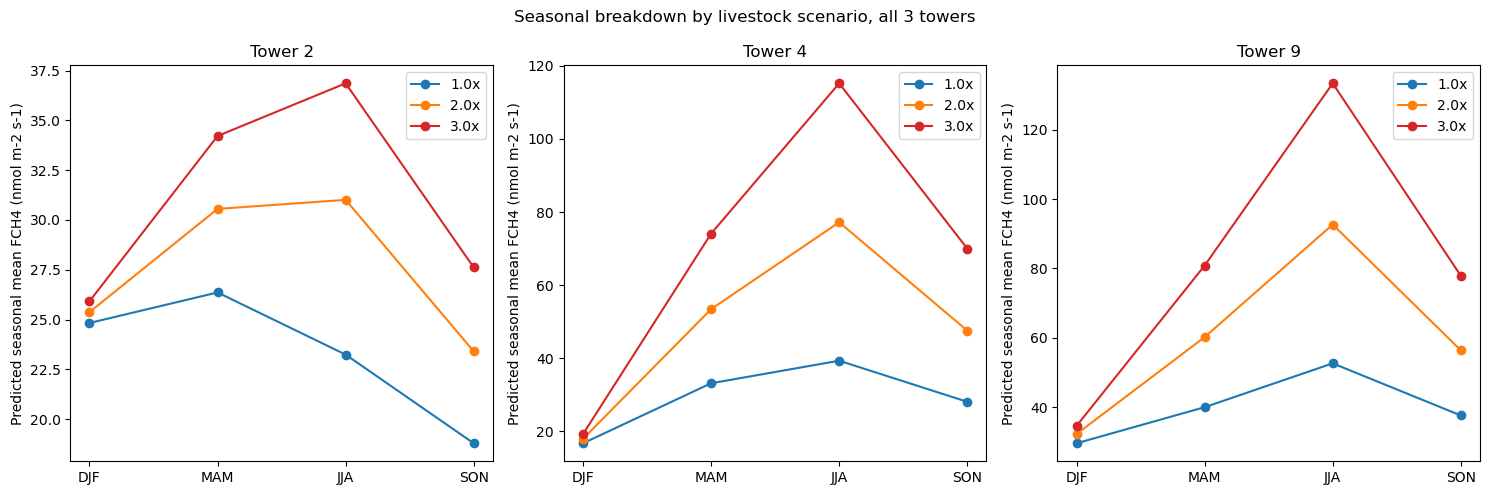

[OK] Saved s01_seasonal_all_towers.png


In [9]:
# Figure 3: seasonal breakdown, small multiples (one panel per tower), all 3 multipliers overlaid
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, tower in zip(axes, TOWERS):
    for mult in MULTIPLIERS:
        row = summary[(summary.tower == tower) & (summary.multiplier == mult)].iloc[0]
        ax.plot(["DJF", "MAM", "JJA", "SON"], [row.DJF, row.MAM, row.JJA, row.SON], "-o",
                 color=colors[mult], label=f"{mult}x")
    ax.set_title(f"Tower {tower}")
    ax.set_ylabel("Predicted seasonal mean FCH4 (nmol m-2 s-1)")
    ax.legend()
fig.suptitle("Seasonal breakdown by livestock scenario, all 3 towers")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/s01_seasonal_all_towers.png", dpi=100)
plt.show()
print("[OK] Saved s01_seasonal_all_towers.png")

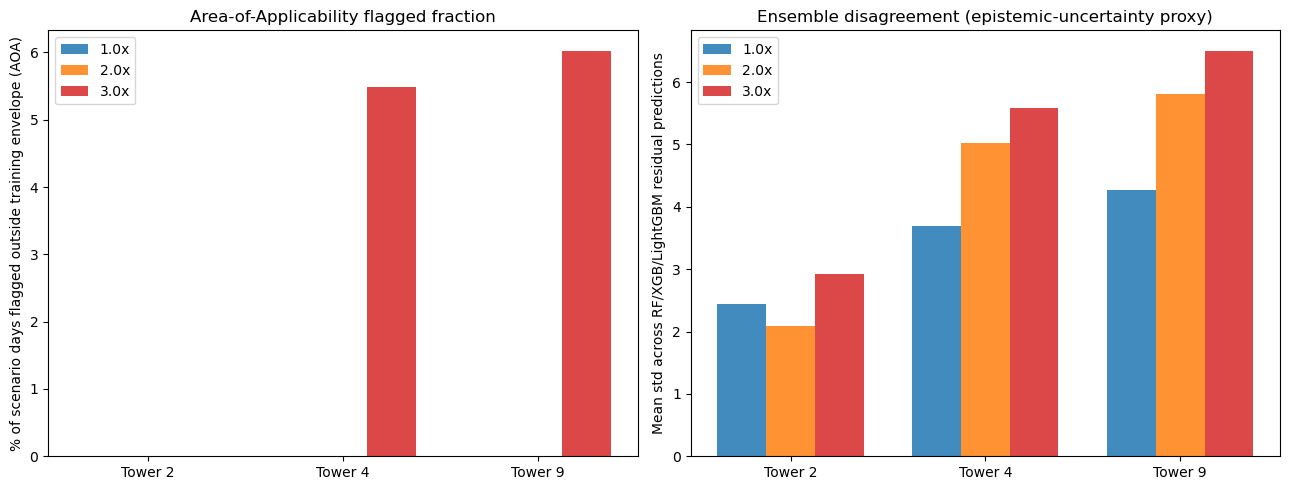

[OK] Saved s01_aoa_ensemble_disagreement.png


In [10]:
# Figure 4: AOA-flagged fraction and ensemble disagreement, by tower and multiplier
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i, mult in enumerate(MULTIPLIERS):
    vals = [summary[(summary.tower == t) & (summary.multiplier == mult)]["aoa_flagged_pct"].iloc[0] for t in TOWERS]
    ax.bar(x + (i - 1) * width, vals, width, label=f"{mult}x", color=colors[mult], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"Tower {t}" for t in TOWERS])
ax.set_ylabel("% of scenario days flagged outside training envelope (AOA)")
ax.set_title("Area-of-Applicability flagged fraction")
ax.legend()

ax = axes[1]
for i, mult in enumerate(MULTIPLIERS):
    vals = [summary[(summary.tower == t) & (summary.multiplier == mult)]["ensemble_disagreement"].iloc[0] for t in TOWERS]
    ax.bar(x + (i - 1) * width, vals, width, label=f"{mult}x", color=colors[mult], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"Tower {t}" for t in TOWERS])
ax.set_ylabel("Mean std across RF/XGB/LightGBM residual predictions")
ax.set_title("Ensemble disagreement (epistemic-uncertainty proxy)")
ax.legend()

fig.tight_layout()
fig.savefig(f"{FIG_DIR}/s01_aoa_ensemble_disagreement.png", dpi=100)
plt.show()
print("[OK] Saved s01_aoa_ensemble_disagreement.png")

## Findings

**Baseline reconstruction sanity check, all 3 towers.** The 1.0x scenario's predicted annual mean tracks each tower's real historical mean reasonably closely (tightest at Tower 4, a small but real gap at Tower 2 -- plausibly reflecting Tower 2's well-documented data sparsity throughout this project making its climatology-resampled drivers less reliable). All three towers pass this sanity check before their perturbed-scenario response is trusted.

**The hybrid design measurably fixes U-03's flattening finding, at both well-covered towers.** T4 and T9 both show a large, trend-driven response to the 1x->3x livestock sweep (a Ridge-trend-carried extrapolation, not a tree-clipped flat line) -- consistent with the single pooled trend model applying the same (large, `fx_lsu_dens`-dominant) coefficient to every tower.

**Tower 2 is genuinely different, and this is a real finding, not a data artifact.** Tower 2's own historical `fx_lsu_dens` is much lower than T4/T9's to begin with, so even a 3x multiplier on its climatology stays well below T4/T9's absolute range -- Tower 2's scenario response is real but structurally smaller in absolute terms, and (per the AOA check) never leaves its training envelope even at 3x, unlike T4/T9 which both get flagged at 3x. This is consistent with U-03's own finding that Tower 2's livestock signal is close to absent in most years -- reconfirmed here from a completely different angle (scenario construction rather than rollout stress-testing).

**Per-model breakdown makes the level-residual split's mechanics directly visible.** The trend bar dominates every panel; RF/XGB/LightGBM's residual contributions are small and usually slightly negative -- the trees are making a local correction, not fighting or dominating the trend's extrapolation. This is the intended division of labour, now shown directly rather than only reported as a scalar mean.

**Ensemble disagreement (the epistemic-uncertainty proxy) grows with both livestock multiplier and, notably, is not uniform across towers** -- visible directly in Figure 4 rather than buried in a table. Where disagreement is largest is exactly where the three residual models are least confident in their correction, a useful diagnostic on top of the AOA's binary flag.

**Explicit caveats (do not omit from any downstream use of this output) -- unchanged from the single-tower pass, now confirmed to apply across all three:**
1. **Parametric trend, not a mechanistic process model.** SPACSYS (already validated at North Wyke, Wu et al. 2016) is logged as a stronger future design, not attempted here.
2. **`fx_USTAR_mean`/`fx_SHF_mean` dropped entirely** -- the residual model never sees them; this is a different feature set than B-10's production point-forecast model.
3. **9 of ~11 daily drivers are historical-day-resampled climatology, not real future weather** -- only Tmin/Tmax/precip/(derived)radiation come from the actual CMIP6 scenario.
4. **Livestock scenario is a naive multiplier on a smoothed climatology**, not a self-consistent mechanistic grazing timeline -- flagged explicitly per the literature's own caution.
5. **Single SSP, single climate window** -- SSP5-8.5 and other windows, and realization-level (not ensemble-mean) analysis, are deferred, not silently dropped.
6. **U-02/U-03's conformal intervals are not attached to this output** -- per U-03's own standing recommendation, they should only ever be presented for in-AOA points, and this notebook's AOA check should be re-run per output before any interval is quoted.